# Étape 2 EXTRA — Analyse des sentiments des conversations

## Notebook annoté

Le but est le même que pour l'étape 2, implémenter un **classificateur de sentiments** sur des textes liés à la santé mentale.  
Ce notebook est une partie complémentaire implémentant une nouvelle méthodes supervisée: BERT.  

Le corpus d'entraînement utilisé est le dataset *Sentiment Analysis for Mental Health* (`Combined_Data.csv`) disponible sur Kaggle.

Nous allons définir 3 modèles différents de BERT:  
- La méthode **sans** aucun *fine-tuning* (permettant de se familiariser avec le modèle)
- Cette méthode **avec** *fine-tuning* sur notre dataset
- Importer un BERT **pré-entraîné sur des analyses de sentiments** (modèle importé depuis [Hugging Face](https://huggingface.co/)) que l'on fine-tune par la suite sur notre dataset

Pour chaque modèle, on appliquera les mêmes analyses que pour l'étape 2 (accuracy score, classification report et matrice de confusion) afin de comparer les modèles entre eux.

---

## Table des matières

- [1. Introduction](#1-introduction)
  - [1.1. Tout d'abord, qu'est ce que BERT ?](#11-tout-dabord-quest-ce-que-bert-)
  - [1.2. Étapes d'apprentissages de BERT](#12-étapes-dapprentissages-de-bert)
  - [1.3. Ce qui fait la force de BERT...](#13-ce-qui-fait-la-force-de-bert)
  - [1.4. ...mais aussi ces faiblesses](#14-mais-aussi-ces-faiblesses)
- [2. Initialisation](#2-initialisation)
  - [2.1. Imports et dépendances](#21-imports-et-dépendances)
  - [2.2. Chargement et préparation des données](#22-chargement-et-préparation-des-données)
  - [2.3. Découpage Train / Test](#23-découpage-train--test)
  - [2.4. Encodage des labels](#24-encodage-des-labels)
- [3. Modèle A — BERT sans fine-tuning (feature extraction)](#3-modèle-a--bert-sans-fine-tuning-feature-extraction)
  - [3.1. Principe et architecture](#31-principe-et-architecture)
  - [3.2. Tokenisation BERT](#32-tokenisation-bert)
  - [3.3. Extraction des embeddings [CLS]](#33-extraction-des-embeddings-cls)
  - [3.4. Classification avec un classifieur léger](#34-classification-avec-un-classifieur-léger)
  - [3.5. Évaluation](#35-évaluation)
- [4. Modèle B — BERT avec fine-tuning](#4-modèle-b--bert-avec-fine-tuning)
  - [4.1. Principe du fine-tuning](#41-principe-du-fine-tuning)
  - [4.2. Préparation du Dataset PyTorch](#42-préparation-du-dataset-pytorch)
  - [4.3. Chargement du modèle et de la tête de classification](#43-chargement-du-modèle-et-de-la-tête-de-classification)
  - [4.4. Boucle d'entraînement](#44-boucle-dentraînement)
  - [4.5. Évaluation](#45-évaluation)
- [5. Modèle C — BERT pré-entraîné sur sentiments (Hugging Face) + fine-tuning](#5-modèle-c--bert-pré-entraîné-sur-sentiments-hugging-face--fine-tuning)
  - [5.1. Pourquoi utiliser un modèle spécialisé ?](#51-pourquoi-utiliser-un-modèle-spécialisé-)
  - [5.2. Chargement du modèle spécialisé](#52-chargement-du-modèle-spécialisé)
  - [5.3. Adaptation de la tête de classification](#53-adaptation-de-la-tête-de-classification)
  - [5.4. Fine-tuning sur notre dataset](#54-fine-tuning-sur-notre-dataset)
  - [5.5. Évaluation](#55-évaluation)
- [6. Comparaison des modèles](#6-comparaison-des-modèles)

---

## 1. Introduction

### 1.1. Tout d'abord, qu'est ce que BERT ?

BERT (*Bidirectional Encoder Representation from Transformer*) est un modèle de language développé par Google en 2018.  

BERT repose sur l'architecture **Transformer**, mais n'en utilise que la partie **encodeur**. Sa particularité fondamentale est d'être **bidirectionnel**: contrairement aux modèles précédents qui lisaient le texte de gauche à droite (ou l'inverse), **BERT lit le contexte dans les deux direction simultanément.**.

> "Le chat mange la souris" → BERT comprend "mange" en regardant à la fois "chat" (gauche) et "souris" (droite).

### 1.2. Étapes d'apprentissages de BERT

**Pré-entraînement (non supervisé)**
Avant toute tâches spécifiques, BERT est pré-entraîné sur d'énormes corpus (Wikipedia, BooksCorpus etc.) via deux tâches:  
- **Masked Language Model (MLM)**: on masque ~15% des tokens au hasard et le modèle doit les prédire. Ex: "Le [MASK] mange la souris" → prédit "chat"
- **Next Sentence Prediction (NSP)**: le modèle apprend si deux phrases se suivent logiquement ou non.

**Fine-tuning supervisé**  
C'est ici qu'intervient l'apprentissage **supervisé**. On reprend BERT pré-entraîné et on l'adapte à un tâche précise avec des données étiquetées, en ajoutant une petite couche de sortie:  

| Tâche | Exemple | Ce qu'on ajoute |
|-|-|-|
| Classification de texte | Sentiment positif/négatif | Couche dense sur le token [CLS] |
| NER | Identifier noms, lieux... | Couche dense sur chaque token |
| Question-Réponse | Extraire la réponse d'un passage | Deux classifieurs (début/fin de span) |
| Similarité de phrases | Les phrases sont-elles équivalentes ? | Couche dense sur [CLS] |

Le fine-tuning ne nécessite que peu de données étiquetées et peu d'epochs, car BERT a déjà appris une représentation riche du langage.

**Tokenisation spécifique**  
BERT utilise **WordPiece tokenizer**: les mots rares sont découpés en sous-mots

```"unhapiness" → ["un", "##happi", "##ness"]```  

Et ajoute des tokens spéciaux:  
- `[CLS]` en début de séquence (représente la phrase entière)
- `[SEP]` pour séparer deux segments  

### 1.3 Ce qui fait la force de BERT...
- Les représentations sont **contextuelles** : le mot "banque" n'a pas le même vecteur dans "banque financière" et "banque de sable".  
- Le transfert de connaissances est très efficace : un BERT pré-entraîné une fois peut être fine-tuné pour des dizaines de tâches différentes.  
- Des variantes existent pour différents besoins : **RoBERTa** (plus robuste), **CamemBERT** (français), **DistilBERT** (plus léger), etc.  

### 1.4 ...mais aussi ces faiblesses

#### Coût computationnel élevé
Probablement la limitation la plus concrète:
- BERT-base: 110 million de paramètres
- BERT-large: 340 millions de paramètres
- L'attention est en $O(n^2)$ par rapport à la longueur de la séquence, donc extrèmement coûteux sur les longs textes
- Fine-tuning et inférence nécessitent un GPU pour être résonnables en temps

#### Limite de longueur des séquences
BERT est limité à **512 tokens** en entrée. C'est un problème réel pour:
- Les documents longs (articles, contrats, rapports)
- Le texte doit être **tronqué ou découpé**, ce qui peut faire perdre du contexte

> Des variantes comme **Longformer** ou **BigBird** ont été créées pour palier ce problème.

---

## 2. Initialisation

### 2.1. Imports et dépendances

Ce notebook nécessite les bibliothèques suivantes :

| Bibliothèque | Rôle |
|---|---|
| `transformers` (Hugging Face) | Chargement des modèles BERT et tokeniseurs pré-entraînés |
| `torch` | Framework deep learning pour l'entraînement et l'inférence |
| `torch.utils.data` | `Dataset` et `DataLoader` pour créer des batchs d'entraînement |
| `sklearn` | Métriques d'évaluation, encodage des labels, découpage train/test |
| `numpy`, `pandas` | Manipulation des données |
| `matplotlib`, `seaborn` | Visualisation des résultats |

> ⚠️ **Prérequis** : installer `transformers` et `torch` si ce n'est pas déjà fait :
> ```bash
> pip install transformers torch
> ```

> 💡 **GPU recommandé** : BERT est très coûteux en calcul. Vérifiez la disponibilité d'un GPU avec `torch.cuda.is_available()`.  
> Sur Google Colab, activer le runtime GPU dans *Exécution → Modifier le type d'exécution*.


**Ce que nous faisons ici:**

1. Importer toutes les bibliothèques listées ci-dessus
2. Détecter et afficher le device disponible (`cuda` ou `cpu`) — toutes les opérations PyTorch devront être effectuées sur ce device
3. Fixer les seeds de reproductibilité (`random`, `numpy`, `torch`) à 42 

In [4]:
# Import des bibliothèques 

# transformers 
import transformers
# torch
import torch
from torch.utils.data import Dataset, DataLoader

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# numpy
import numpy as np
# pandas
import pandas as pd
# matplotlib
import matplotlib.pyplot as plt
# seaborn
import seaborn as sns
# regex
import re

c:\Users\diogo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# On détecte et affiche le device disponible (cuda ou cpu)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [6]:
# On fixe les seeds de reproductibilité
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

### 2.2. Chargement et préparation des données

On réutilise exactement le même pipeline de nettoyage que dans le notebook principal (ETAPE2) :  
chargement → mélange → suppression des NaN → suppression des conflits → nettoyage du texte (`cleaner`).

> ⚠️ **Ne pas** réappliquer la tokenisation NLTK ni la vectorisation BoW/TF-IDF/Word2Vec : BERT dispose de son propre tokeniseur (`BertTokenizer`) qui sera utilisé directement sur le texte nettoyé.

**Ce que nous faisons ici :**

1. Charger `Combined_Data.csv` dans un DataFrame `df`
2. Mélanger les lignes (`sample(frac=1, random_state=42)`) et réinitialiser l'index
3. Supprimer les lignes avec des valeurs manquantes (`dropna`)
4. Supprimer les énoncés avec des étiquettes conflictuelles (même logique que dans le notebook principal)
5. Appliquer la fonction `cleaner` sur la colonne `statement`
6. Séparer `X` (textes nettoyés) et `y` (labels)

In [2]:
# Fonction cleanner pour nettoyer les énoncés
def cleaner(text):
    text = re.sub(r'\s*@\w+', '', text)                            # remove words starting with @ 
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)            # remove URLs 
    text = re.sub(r'<[^>]*>', '', text)                            # remove all of the HTML markup
    #text = re.sub(r'\b\w\b', '', text)                             # remove single letters, I, a, ...
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)  # find emoticons (emoji)
    text = (re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')) 
    #  replace any non_word with space, lowercase words, add emojis at the end
    return text

In [ ]:
import pandas as pd
# On charge combined_data.csv
df=pd.read_csv("../../data/combined_data.csv",index_col=0)
# On mélange les lignes du dataframe et on réinitialise les index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# On supprime les lignes avec des valeurs manquantes
df = df.dropna()
# On supprime les énoncés avec des étiquettes conflictuelles
df = df[df.groupby('statement')['status'].transform('nunique') == 1]
# On applique la fonction cleaner sur la colonne statement
df.loc[:, 'statement'] = df['statement'].apply(cleaner)
# On sépare X (textes nettoyés) et y (labels)
X = df['statement']
y = df['status']

### 2.3. Découpage Train / Test

Contrairement au notebook principal, un simple découpage en deux ensembles suffit ici. Le fine-tuning de BERT converge rapidement (2–3 epochs) et les hyperparamètres sont peu nombreux, ce qui rend l'ensemble de validation optionnel.

**Ce que nous faisons ici:**

1. Effectuer un `train_test_split` (80% train, 20% test) avec `stratify=y` et `random_state=42`
2. Afficher les tailles de chaque ensemble

In [8]:
# Découpage Train/Test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 42105 | Test size: 10527


### 2.4. Encodage des labels

PyTorch exige des **entiers** comme labels (et non des chaînes de caractères). On utilise `LabelEncoder` de `sklearn.preprocessing` pour convertir les étiquettes textuelles en indices numériques.

> ⚠️ Le `LabelEncoder` doit être fitté **uniquement sur `y_train`**, puis appliqué en `.transform` sur `y_val` et `y_test`. Cela évite tout data leakage.

**Ce que nous faisons ici:**

1. Instancier un `LabelEncoder` et le fitter sur `y_train`
2. Transformer `y_train` et `y_test` en tableaux d'entiers
3. Afficher le mapping label → entier (`encoder.classes_`) et le nombre de classes (`num_labels`)

> 💡 COn conserve le `LabelEncoder` fitté pour l'inférence finale : il permettra de reconvertir les prédictions numériques en noms de sentiments.

In [9]:
# Encodage des labels avec LabelEncoder (fit uniquement sur y_train)
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)
num_labels = len(encoder.classes_)
print('Label classes:', encoder.classes_)
print('Num labels:', num_labels)

Label classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']
Num labels: 7


---

## 3. Modèle A — BERT sans fine-tuning (feature extraction)

### 3.1. Principe et architecture

Dans cette première approche, **les poids de BERT sont gelés** (non modifiés pendant l'entraînement). BERT est utilisé comme un **extracteur de features** : il produit des représentations vectorielles riches pour chaque texte, et un classifieur léger (`LogisticRegression`) apprend à partir de ces vecteurs.

```mermaid
flowchart LR
A[Texte brut]
B[Tokens + masques]
C[Embedding `CLS` 
vecteur de 768 dimensions]
D[Classe prédite]

A -->|BertTokenizer| B
B --> |BertModel
poids gelés| C
C --> |LogisticRegression| D
```

**Pourquoi commencer par cette méthode ?**

| Avantage | Inconvénient |
|---|---|
| Très rapide (pas de backprop dans BERT) | Performances souvent inférieures au fine-tuning |
| Peu de mémoire GPU nécessaire | BERT n'est pas adapté à la tâche spécifique |
| Sert de baseline solide | Les embeddings [CLS] sans fine-tuning sont génériques |

> 💡 **Le token `[CLS]`** est le premier token de chaque séquence BERT. Dans les modèles fine-tunés, sa représentation encode l'information globale de la phrase. Sans fine-tuning, il capture une représentation générale du texte apprise lors du pré-entraînement sur Wikipedia/BooksCorpus.

### 3.2. Tokenisation BERT

Le `BertTokenizer` convertit chaque texte en une séquence d'identifiants de tokens compréhensibles par BERT. Il gère automatiquement :
- L'ajout des tokens spéciaux `[CLS]` et `[SEP]`
- Le padding (remplissage) et la troncature à `max_length` tokens
- La création des `attention_mask` (1 pour les vrais tokens, 0 pour le padding)

Le paramètre `max_length=128` est un compromis entre couverture du texte et coût computationnel. La limite absolue de BERT est 512 tokens.

**Ce que vous devez faire :**

1. Charger le tokeniseur `BertTokenizer.from_pretrained('bert-base-uncased')`
2. Tokeniser `X_train` et `X_test` avec les paramètres suivants :
   - `padding='max_length'`, `truncation=True`, `max_length=128`, `return_tensors='pt'`
3. Pour chaque ensemble, stocker les `input_ids` et `attention_mask` résultants
4. Afficher la forme d'un tenseur pour vérification

In [10]:
from transformers import BertTokenizer, BertModel
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_model = BertModel.from_pretrained(
    "bert-base-uncased"
).to(device)

# Mode inference uniquement
bert_model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3726.46it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### 3.3. Extraction des embeddings [CLS]

On fait passer les textes tokenisés à travers `BertModel` pour récupérer les représentations produites par BERT. Le vecteur associé au token `[CLS]` (premier token, position 0 de la dernière couche cachée) est utilisé comme représentation globale du texte.

> ⚠️ **Mode inférence uniquement** : utiliser `torch.no_grad()` pour désactiver le calcul des gradients — inutile ici puisque les poids ne sont pas mis à jour. Cela réduit significativement la consommation mémoire.

> ⚠️ **Travailler en batchs** : passer tous les textes d'un coup peut saturer la mémoire GPU. Diviser les données en batchs de 32 ou 64 exemples avec une boucle.

**Ce que vous devez faire :**

1. Charger `BertModel.from_pretrained('bert-base-uncased')` et le placer sur le device
2. Passer le modèle en mode évaluation (`.eval()`)
3. Écrire une fonction `extract_cls_embeddings(input_ids, attention_mask, model, batch_size=32)` qui :
   - Itère sur les données par batchs
   - Effectue le passage avant (`model(...)`) dans un contexte `torch.no_grad()`
   - Récupère `last_hidden_state[:, 0, :]` (vecteur [CLS]) pour chaque batch
   - Retourne un tableau numpy de shape `(n_samples, 768)`
4. Appliquer cette fonction sur train et test
5. Afficher les dimensions des embeddings obtenus (`X_train_cls.shape`, `X_test_cls.shape`)

In [11]:
def get_bert_embeddings(texts, batch_size=32):

    embeddings = []


    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size].tolist()

        # Tokenization
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )

        # Envoi GPU
        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        # Inference BERT
        with torch.no_grad():

            outputs = bert_model(**inputs)

        # CLS token embedding
        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        # Retour CPU numpy
        embeddings.append(
            cls_embeddings.cpu().numpy()
        )


    return np.vstack(embeddings)

# =========================================================
# EMBEDDINGS
# =========================================================

print("\nExtraction embeddings TRAIN")
X_train_bert = get_bert_embeddings(X_train)

print("\nExtraction embeddings TEST")
X_test_bert = get_bert_embeddings(X_test)

print("\nShape train :", X_train_bert.shape)
print("Shape test  :", X_test_bert.shape)



Extraction embeddings TRAIN

Extraction embeddings TEST

Shape train : (42105, 768)
Shape test  : (10527, 768)


### 3.4. Classification avec un classifieur léger

Les embeddings extraits sont des vecteurs numériques de dimension 768 — exactement le format attendu par les classifieurs de `sklearn`. On utilise ici une **régression logistique** (rapide et efficace sur des features de haute dimension).

**Ce que vous devez faire :**

1. Instancier un `LogisticRegression(max_iter=1000, random_state=42)` depuis `sklearn.linear_model`
2. L'entraîner sur les embeddings d'entraînement (`X_train_cls`, `y_train_enc`)
3. Générer les prédictions sur `X_test_cls` et les stocker dans `y_pred_A`

> 💡 On pourrait aussi utiliser un `SVC`, un `RandomForestClassifier` ou même un petit réseau dense à la place de la régression logistique. La régression logistique est choisie ici pour sa rapidité et son interprétabilité.

In [12]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

clf.fit(X_train_bert, y_train_enc)

c:\Users\diogo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### 3.5. Évaluation

**Ce que vous devez faire :**

Calculer et afficher les métriques suivantes sur `y_test_enc` vs `y_pred_A` :

| Métrique | Fonction sklearn |
|---|---|
| **Accuracy** | `accuracy_score` |
| **Classification report** | `classification_report` (avec `target_names=encoder.classes_`) |
| **Matrice de confusion** | `ConfusionMatrixDisplay.from_predictions` |

> 💡 Penser à faire pivoter les étiquettes en abscisse de la matrice de confusion (`plt.xticks(rotation=45, ha='right')`) pour la lisibilité.

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    r2_score,
    classification_report,
    ConfusionMatrixDisplay
)
def evaluate(name, y_true_enc, y_pred_enc):
   

    acc = accuracy_score(y_true_enc, y_pred_enc)
    mse = mean_squared_error(y_true_enc, y_pred_enc)
    r2  = r2_score(y_true_enc, y_pred_enc)

    print(f"\n{'═'*50}")
    print(f"  {name}")
    print(f"{'═'*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  MSE      : {mse:.4f}")
    print(f"  R²       : {r2:.4f}")

    print(
        classification_report(
            y_true_enc,
            y_pred_enc,
            target_names=encoder.classes_
        )
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    ConfusionMatrixDisplay.from_predictions(
        y_true_enc,
        y_pred_enc,
        display_labels=encoder.classes_,
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"Confusion Matrix — {name}",
        fontsize=13,
        fontweight='bold'
    )

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    return acc, mse, r2, y_pred_enc


 Prédictions

══════════════════════════════════════════════════
  BERT  + LogisticRegression
══════════════════════════════════════════════════
  Accuracy : 0.7231
  MSE      : 3.0199
  R²       : 0.0515
                      precision    recall  f1-score   support

             Anxiety       0.73      0.67      0.70       767
             Bipolar       0.68      0.62      0.65       555
          Depression       0.64      0.70      0.67      3076
              Normal       0.88      0.93      0.91      3268
Personality disorder       0.56      0.38      0.45       215
              Stress       0.52      0.42      0.46       517
            Suicidal       0.65      0.59      0.62      2129

            accuracy                           0.72     10527
           macro avg       0.67      0.62      0.64     10527
        weighted avg       0.72      0.72      0.72     10527



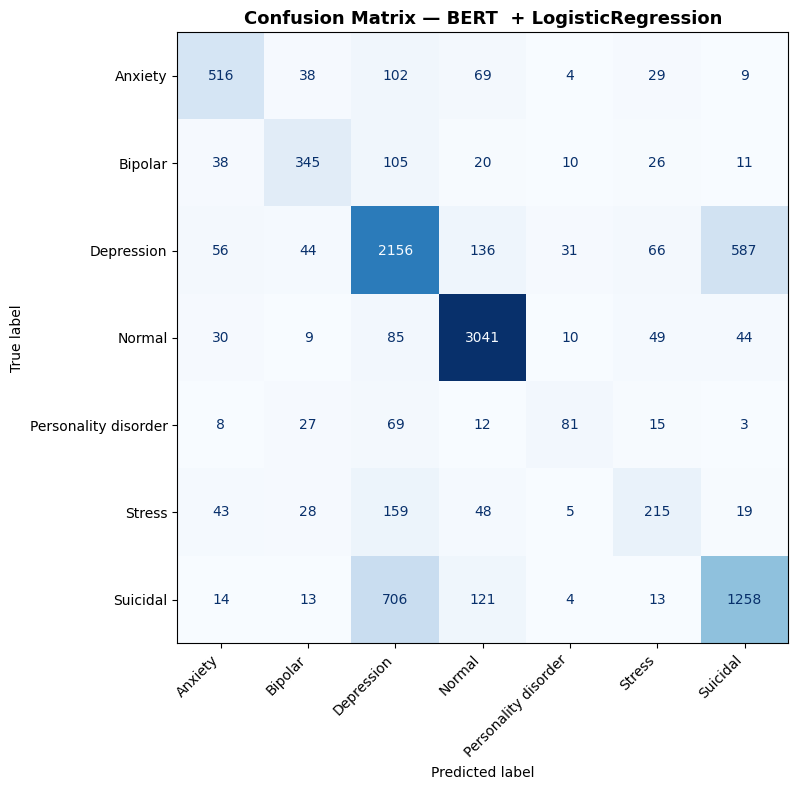

(0.723092998955068,
 3.0198537095088818,
 0.05154276024412885,
 array([2, 6, 3, ..., 1, 6, 3], shape=(10527,)))

In [14]:
print("\n Prédictions")

predictions = clf.predict(X_test_bert)

# =========================================================
# ÉVALUATION
# =========================================================

evaluate(
    "BERT  + LogisticRegression",
    y_test_enc,
    predictions
)

---

## 4. Modèle B — BERT avec fine-tuning

### 4.1. Principe du fine-tuning

Dans cette seconde approche, **tous les poids de BERT sont mis à jour** pendant l'entraînement, y compris les couches d'attention. On ajoute en sortie une **tête de classification** (couche `Linear`) qui projette le vecteur `[CLS]` vers les `num_labels` classes.

```mermaid
flowchart LR

    A["Texte brut"] --> B["BertTokenizer"] --> C["Tokens + masques"]

    C --> D["BertForSequenceClassification"]

    subgraph S1 [" "]
        direction LR
        E["BertModel"] --> F["Dropout + Linear<br/>(768 → num_labels)"]
    end

    D --> E
    F --> G["Logits"]

    G --> H["CrossEntropyLoss"]
    H --> I["Gradient"]
    I --> J["Optimiseur"]

    J -.-> K["Poids mis à jour<br/>par backprop"]
    K -.-> D
```

**Comparaison avec le Modèle A :**

| | Modèle A (sans fine-tuning) | Modèle B (avec fine-tuning) |
|---|---|---|
| Poids BERT | Gelés | Mis à jour |
| Temps d'entraînement | Court | Long (GPU recommandé) |
| Mémoire | Faible | Élevée |
| Performances attendues | Baseline | Meilleures |
| Données nécessaires | Peu | Quelques milliers suffisent |

> 💡 Hugging Face fournit `BertForSequenceClassification` qui intègre directement BERT + la tête de classification. Pas besoin de définir l'architecture manuellement.

### 4.2. Préparation du Dataset PyTorch

PyTorch utilise des objets `Dataset` et `DataLoader` pour gérer l'itération sur les données par batchs pendant l'entraînement. Il faut créer une classe `MentalHealthDataset` qui encapsule les tenseurs tokenisés et les labels.

**Ce que vous devez faire :**

1. Créer une classe `MentalHealthDataset(torch.utils.data.Dataset)` avec :
   - `__init__(self, input_ids, attention_mask, labels)` : stocke les tenseurs
   - `__len__` : retourne le nombre d'exemples
   - `__getitem__` : retourne un dictionnaire `{'input_ids': ..., 'attention_mask': ..., 'labels': ...}` pour l'index `idx`

2. Instancier deux datasets (`train_dataset`, `test_dataset`) à partir des tenseurs tokenisés de la section 3.2 et des labels encodés de la section 2.4

3. Créer deux `DataLoader` avec :
   - `batch_size=16` (ou 32 selon la mémoire GPU disponible)
   - `shuffle=True` pour le train uniquement

> 💡 Un `DataLoader` avec `shuffle=True` regroupe les exemples en batchs et les mélange à chaque epoch — cela stabilise l'entraînement et évite que le modèle apprenne l'ordre des données.

In [15]:
# =========================================================
# 4. DATASET PYTORCH PERSONNALISÉ
# =========================================================

from torch.utils.data import Dataset, DataLoader

class MentalHealthDataset(Dataset):

    def __init__(
        self,
        input_ids,
        attention_mask,
        labels
    ):

        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

# =========================================================
# 5. TOKENIZATION
# =========================================================

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

# TRAIN
train_tokens = tokenizer(
    X_train.tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# TEST
test_tokens = tokenizer(
    X_test.tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# =========================================================
# 6. DATASETS
# =========================================================

train_dataset = MentalHealthDataset(
    input_ids=train_tokens["input_ids"],
    attention_mask=train_tokens["attention_mask"],
    labels=y_train_enc
)

test_dataset = MentalHealthDataset(
    input_ids=test_tokens["input_ids"],
    attention_mask=test_tokens["attention_mask"],
    labels=y_test_enc
)

# =========================================================
# 7. DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

# =========================================================
# 8. VÉRIFICATION
# =========================================================

batch = next(iter(train_loader))

print("input_ids shape      :", batch["input_ids"].shape)
print("attention_mask shape :", batch["attention_mask"].shape)
print("labels shape         :", batch["labels"].shape)

input_ids shape      : torch.Size([16, 128])
attention_mask shape : torch.Size([16, 128])
labels shape         : torch.Size([16])


### 4.3. Chargement du modèle et de la tête de classification

`BertForSequenceClassification` est le modèle BERT officiel pour la classification de texte. Il intègre automatiquement :
- Le `BertModel` de base (12 couches Transformer)
- Un `Dropout(0.1)` sur le vecteur `[CLS]`
- Une couche `Linear(768, num_labels)` comme tête de classification

Le paramètre `num_labels` doit correspondre au nombre de classes dans votre dataset.

**Ce que vous devez faire :**

1. Charger `BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)` et le placer sur le device
2. Instancier l'optimiseur `AdamW` (de `transformers` ou `torch.optim`) avec un **learning rate de 2e-5** (valeur recommandée pour le fine-tuning BERT)
3. Instancier un `get_linear_schedule_with_warmup` (de `transformers`) avec :
   - `num_warmup_steps = 0`
   - `num_training_steps = num_epochs × len(train_loader)`

> 💡 **Pourquoi un scheduler ?** Le learning rate démarre à 2e-5 puis décroît linéairement jusqu'à 0. Cela évite des mises à jour trop agressives en fin d'entraînement, ce qui peut déstabiliser les poids pré-entraînés de BERT.

> 💡 **Pourquoi AdamW et pas Adam ?** AdamW corrige une erreur dans l'implémentation de la *weight decay* d'Adam. Google recommande AdamW pour le fine-tuning BERT.

In [ ]:
# =========================================================
# 4.3. MODÈLE + OPTIMIZER + SCHEDULER
# =========================================================

from transformers import (
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW

# =========================================================
# DEVICE GPU
# =========================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        " GPU non détecté"
    )

device = torch.device("cuda")

print("GPU :", torch.cuda.get_device_name(0))

# =========================================================
# CHARGEMENT DU MODÈLE BERT
# =========================================================

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

# Envoi GPU
model.to(device)

print("Modèle chargé sur GPU")

# =========================================================
# OPTIMIZER : AdamW
# =========================================================

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

print("Optimizer AdamW initialisé")

# =========================================================
# SCHEDULER
# =========================================================

# Nombre d'epochs
num_epochs = 3

# Nombre total de batchs d'entraînement
total_steps = len(train_loader) * num_epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("Scheduler initialisé")

print("\nNombre total de steps :", total_steps)

GPU : NVIDIA GeForce RTX 2060


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4084.61it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Modèle chargé sur GPU
Optimizer AdamW initialisé
Scheduler initialisé

Nombre total de steps : 7896


### 4.4. Boucle d'entraînement

La boucle d'entraînement suit le schéma classique de PyTorch, répété sur `num_epochs` epochs (2 à 4 suffisent généralement pour BERT) :

```
Pour chaque epoch:
    model.train()
    Pour chaque batch:
        1. Envoyer le batch sur le device
        2. Passer en avant (forward) → obtenir les logits et la loss
        3. Rétropropager (loss.backward())
        4. Clipper les gradients (clip_grad_norm_, max_norm=1.0)
        5. Mettre à jour les poids (optimizer.step())
        6. Mettre à jour le scheduler (scheduler.step())
        7. Remettre les gradients à zéro (optimizer.zero_grad())
    Afficher la loss moyenne de l'epoch
```

> ⚠️ **`clip_grad_norm_`** (avec `max_norm=1.0`) est essentiel pour BERT : il empêche les gradients d'exploser lors des premières epochs, ce qui peut déstabiliser les poids pré-entraînés.

> ⚠️ **Temps d'exécution estimé** : environ 15–30 min par epoch sur GPU (Colab T4), 2–3 heures sur CPU. **Utiliser un GPU est fortement recommandé.**

**Ce que vous devez faire :**

1. Fixer `num_epochs = 3`
2. Implémenter la boucle d'entraînement décrite ci-dessus
3. Afficher la loss d'entraînement moyenne à la fin de chaque epoch

In [17]:
# =========================================================
# 4.4. BOUCLE D'ENTRAÎNEMENT BERT
# =========================================================

from tqdm import tqdm
from torch.nn.utils import clip_grad_norm_

# =========================================================
# Nombre d'epochs
# =========================================================

num_epochs = 3

# =========================================================
# Mode entraînement
# =========================================================

print("Début du fine-tuning BERT...\n")

# =========================================================
# LOOP EPOCHS
# =========================================================

for epoch in range(num_epochs):

    print(f"{'='*60}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*60}")

    # Mode train
    model.train()

    total_train_loss = 0

    # =====================================================
    # LOOP BATCHS
    # =====================================================

    progress_bar = tqdm(train_loader)

    for batch in progress_bar:

        # =================================================
        # 1. ENVOI GPU
        # =================================================

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # =================================================
        # 2. RESET GRADIENTS
        # =================================================

        optimizer.zero_grad()

        # =================================================
        # 3. FORWARD PASS
        # =================================================

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # =================================================
        # 4. BACKPROPAGATION
        # =================================================

        loss.backward()

        # =================================================
        # 5. CLIPPING DES GRADIENTS
        # =================================================

        clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # =================================================
        # 6. UPDATE POIDS
        # =================================================

        optimizer.step()

        # =================================================
        # 7. UPDATE LEARNING RATE
        # =================================================

        scheduler.step()

        # =================================================
        # LOSS
        # =================================================

        total_train_loss += loss.item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    # =====================================================
    # LOSS MOYENNE EPOCH
    # =====================================================

    avg_train_loss = total_train_loss / len(train_loader)

    print(f"\n Loss moyenne : {avg_train_loss:.4f}\n")

Début du fine-tuning BERT...

Epoch 1/3


100%|██████████| 2632/2632 [15:31<00:00,  2.83it/s, loss=1.0757]



 Loss moyenne : 0.6361

Epoch 2/3


100%|██████████| 2632/2632 [15:44<00:00,  2.79it/s, loss=0.2545]



 Loss moyenne : 0.3871

Epoch 3/3


100%|██████████| 2632/2632 [15:49<00:00,  2.77it/s, loss=0.3635]


 Loss moyenne : 0.2705



### 4.5. Évaluation

**Ce que vous devez faire :**

1. Écrire une fonction `predict(model, dataloader, device)` qui :
   - Passe le modèle en mode évaluation
   - Itère sur les batchs du `DataLoader` avec `torch.no_grad()`
   - Applique `argmax` sur les logits pour obtenir les classes prédites
   - Retourne deux tableaux numpy : `y_true` et `y_pred`

2. Appliquer cette fonction sur `test_loader` pour obtenir `y_pred_B`

3. Calculer et afficher les mêmes métriques que pour le Modèle A :

| Métrique | Fonction sklearn |
|---|---|
| **Accuracy** | `accuracy_score` |
| **Classification report** | `classification_report` |
| **Matrice de confusion** | `ConfusionMatrixDisplay.from_predictions` |

Évaluation du modèle BERT...


══════════════════════════════════════════════════
  BERT Fine-Tuning
══════════════════════════════════════════════════
  Accuracy : 0.8302
  MSE      : 2.1319
  R²       : 0.3304
                      precision    recall  f1-score   support

             Anxiety       0.88      0.89      0.89       767
             Bipolar       0.86      0.85      0.86       555
          Depression       0.78      0.77      0.78      3076
              Normal       0.95      0.95      0.95      3268
Personality disorder       0.77      0.68      0.72       215
              Stress       0.73      0.76      0.74       517
            Suicidal       0.72      0.73      0.72      2129

            accuracy                           0.83     10527
           macro avg       0.81      0.81      0.81     10527
        weighted avg       0.83      0.83      0.83     10527



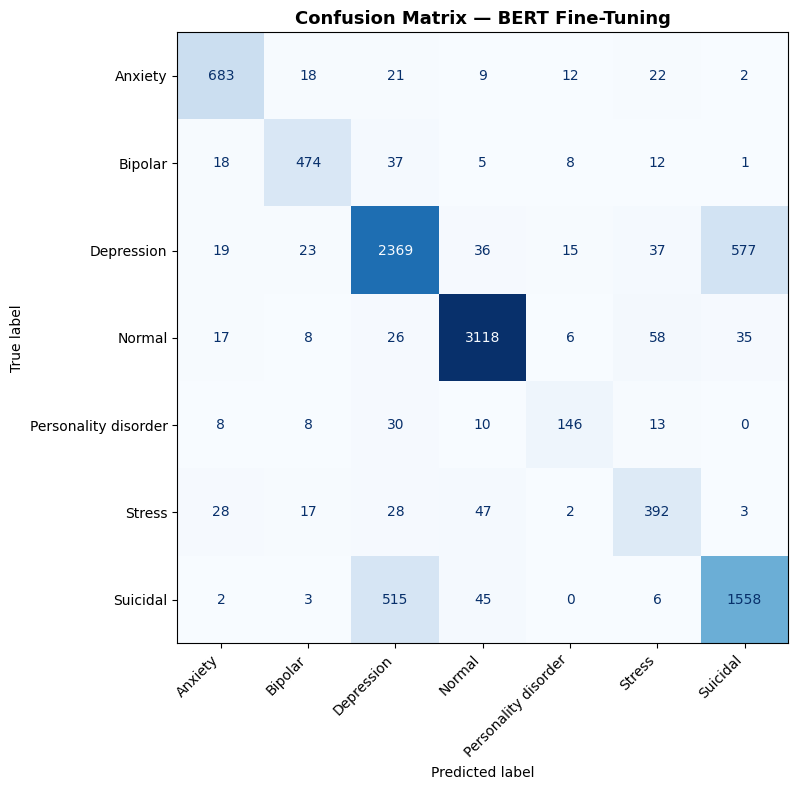

(0.8302460340077895,
 2.1319464234824737,
 0.33041126669263876,
 array([2, 6, 0, ..., 1, 2, 6], shape=(10527,)))

In [18]:
# =========================================================
# 4.5. ÉVALUATION DU MODÈLE BERT
# =========================================================

import numpy as np
import torch

# =========================================================
# FONCTION PREDICT
# =========================================================

def predict(model, dataloader, device):

    # Mode évaluation
    model.eval()

    y_true = []
    y_pred = []

    # Désactive les gradients
    with torch.no_grad():

        # Parcours des batchs
        for batch in dataloader:

            # =============================================
            # Envoi GPU
            # =============================================

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # =============================================
            # FORWARD PASS
            # =============================================

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            # =============================================
            # PRÉDICTIONS
            # =============================================

            predictions = torch.argmax(
                logits,
                dim=1
            )

            # =============================================
            # STOCKAGE
            # =============================================

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )

    return np.array(y_true), np.array(y_pred)

# =========================================================
# PRÉDICTIONS TEST
# =========================================================

print("Évaluation du modèle BERT...\n")

y_true_B, y_pred_B = predict(
    model,
    test_loader,
    device
)

# =========================================================
# MÉTRIQUES
# =========================================================

evaluate(
    "BERT Fine-Tuning",
    y_true_B,
    y_pred_B
)

---

## 5. Modèle C — BERT pré-entraîné sur sentiments (Hugging Face) + fine-tuning

### 5.1. Pourquoi utiliser un modèle spécialisé ?

Le Modèle B part de `bert-base-uncased`, pré-entraîné sur Wikipedia et BooksCorpus — un texte très différent du langage émotionnel ou clinique. Le Modèle C part d'un BERT **déjà fine-tuné sur des tâches d'analyse de sentiments**, ce qui lui donne une meilleure représentation initiale des émotions avant même de voir notre dataset.

```mermaid
flowchart LR

    A["bert-base-uncased"]
    B["Pré-entraîné sur<br/>Wikipedia / BooksCorpus<br/>(langage général)"]
    C["Fine-tuning sur datasets<br/>de sentiments<br/>(Twitter, avis clients...)"]
    D["Modèle spécialisé<br/>(point de départ du Modèle C)"]
    E["Fine-tuning sur notre dataset<br/>(santé mentale)"]
    F["Modèle C final"]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
```

**Modèle recommandé** : [`cardiffnlp/twitter-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment) ou [`distilbert-base-uncased-finetuned-sst-2-english`](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).

> 💡 **DistilBERT** est une version allégée de BERT (66M de paramètres contre 110M) : 40% plus rapide, 60% plus léger, avec ~97% des performances. Il est particulièrement adapté si vous disposez de ressources GPU limitées.

| | BERT-base (Modèle B) | Modèle spécialisé (Modèle C) |
|---|---|---|
| Pré-entraînement initial | Wikipedia / BooksCorpus | Wikipedia / BooksCorpus |
| Fine-tuning intermédiaire | ❌ | ✅ Sentiments (SST-2, Twitter...) |
| Point de départ | Général | Spécialisé |
| Fine-tuning sur notre data | ✅ | ✅ |
| Performances attendues | Bonnes | Meilleures (théoriquement) |

### 5.2. Chargement du modèle spécialisé

**Ce que vous devez faire :**

1. Choisir un modèle pré-entraîné sur des sentiments depuis Hugging Face. Exemples de modèles disponibles :

| Modèle | Avantages | Identifiant Hugging Face |
|---|---|---|
| DistilBERT SST-2 | Léger, rapide | `distilbert-base-uncased-finetuned-sst-2-english` |
| RoBERTa Twitter | Entraîné sur du texte informel | `cardiffnlp/twitter-roberta-base-sentiment` |
| BERT multilingual | Supporte plusieurs langues | `nlptown/bert-base-multilingual-uncased-sentiment` |

2. Charger le tokeniseur correspondant (`AutoTokenizer.from_pretrained(model_name)`)
3. Re-tokeniser `X_train` et `X_test` avec ce nouveau tokeniseur (même paramètres que section 3.2)
4. Recréer les `Dataset` et `DataLoader` avec les nouveaux tenseurs

> ⚠️ Chaque modèle Hugging Face a son propre tokeniseur. Utiliser `AutoTokenizer` plutôt que `BertTokenizer` directement permet de charger automatiquement le bon tokeniseur associé au modèle choisi.

In [ ]:
# 5.2 — Votre code ici

### 5.3. Adaptation de la tête de classification

Le modèle importé a été fine-tuné pour un certain nombre de classes (souvent 2 ou 3 pour des tâches positif/négatif/neutre). Notre dataset a `num_labels` classes différentes. Il faut donc **remplacer la tête de classification** par une nouvelle couche adaptée à notre nombre de classes.

**Ce que vous devez faire :**

1. Charger le modèle avec `AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, ignore_mismatched_sizes=True)` et le placer sur le device

   > 💡 Le paramètre `ignore_mismatched_sizes=True` est nécessaire car la tête de classification originale (ex. 2 classes) est remplacée par une nouvelle tête à `num_labels` classes — les dimensions ne correspondent plus.

2. Instancier un nouvel optimiseur `AdamW` et un scheduler (mêmes hyperparamètres que section 4.3)

3. Afficher l'architecture du modèle pour vérifier que la couche de sortie a bien `num_labels` neurones

In [ ]:
# 5.3 — Votre code ici

### 5.4. Fine-tuning sur notre dataset

La boucle d'entraînement est identique à celle du Modèle B (section 4.4). Seul le modèle chargé change.

> 💡 **Peut-on réutiliser exactement le même code ?** Oui, à condition d'avoir recréé les `DataLoader` avec le tokeniseur du modèle C (section 5.2). La boucle d'entraînement elle-même est indépendante du modèle choisi.

**Ce que vous devez faire :**

1. Réutiliser la même boucle d'entraînement que la section 4.4 (ou l'encapsuler dans une fonction réutilisable `train_model(model, train_loader, optimizer, scheduler, num_epochs, device)`)
2. Afficher la loss d'entraînement à chaque epoch
3. (Optionnel) Comparer les courbes de loss par epoch avec le Modèle B sur un même graphique

> ⚠️ **Temps d'exécution** : similaire au Modèle B. Si vous utilisez DistilBERT, comptez environ 40% de temps en moins par rapport à BERT-base.

In [ ]:
# 5.4 — Votre code ici

### 5.5. Évaluation

**Ce que vous devez faire :**

1. Appliquer la fonction `predict` (définie en section 4.5) sur `test_loader_C` pour obtenir `y_pred_C`

2. Calculer et afficher les métriques :

| Métrique | Fonction sklearn |
|---|---|
| **Accuracy** | `accuracy_score` |
| **Classification report** | `classification_report` |
| **Matrice de confusion** | `ConfusionMatrixDisplay.from_predictions` |

In [ ]:
# 5.5 — Votre code ici

---

## 6. Comparaison des modèles

Cette section synthétise les performances des trois modèles BERT et les compare avec les méthodes du notebook principal (Naive Bayes, K-Means).

**Ce que vous devez faire :**

### 6.1. Tableau récapitulatif

Construire un DataFrame pandas résumant les performances de chaque modèle :

| Modèle | Accuracy (test) | Temps d'entraînement (approx.) | Commentaire |
|---|---|---|---|
| Naive Bayes + TF-IDF | ? | ? | Référence notebook principal |
| K-Means + Word2Vec | ? | ? | Référence notebook principal |
| BERT sans fine-tuning (A) | ? | ? | |
| BERT avec fine-tuning (B) | ? | ? | |
| BERT spécialisé + fine-tuning (C) | ? | ? | |

```python
# 6.1 — Votre code ici
```

In [ ]:
# 6.1 — Votre code ici

### 6.2. Visualisation comparative

**Ce que vous devez faire :**

Tracer un graphique en barres comparant l'accuracy des 5 modèles (Naive Bayes, K-Means, BERT A, BERT B, BERT C). Mettre en évidence le meilleur modèle.

> 💡 Utiliser une couleur distincte pour les modèles BERT vs les méthodes classiques, afin de rendre la comparaison visuelle plus lisible.

In [ ]:
# 6.2 — Votre code ici

### 6.3. Analyse et conclusion

Répondre aux questions suivantes dans cette cellule markdown :

1. **Quel modèle obtient la meilleure accuracy ?** Est-ce le résultat attendu ?
2. **Le gain du fine-tuning** (Modèle B vs Modèle A) : à combien estime-t-on l'apport du fine-tuning ?
3. **Modèle spécialisé vs BERT-base** (Modèle C vs Modèle B) : le modèle pré-entraîné sur des sentiments apporte-t-il un avantage mesurable ?
4. **Compromis coût/performance** : si l'on doit choisir un modèle pour un déploiement en production avec contraintes de temps de réponse, lequel recommandez-vous et pourquoi ?
5. **Quelles classes sont les plus difficiles** pour les modèles BERT ? Comparer avec les résultats de Naive Bayes.

*Votre analyse ici*